# Notebook 3 — Pipeline d'inférence
*C. elegans* | YOLOv8-pose → Random Forest

**Entrée** : vidéo `.avi` | **Sortie** : comportement prédit + keypoints


## 1. Imports

In [15]:
%pip install ultralytics==8.3.0 numpy==1.26.4 -q

Note: you may need to restart the kernel to use updated packages.


In [16]:
import os, warnings, random, glob
os.environ['WANDB_DISABLED'] = 'true'
warnings.filterwarnings('ignore')
import numpy as np
import cv2, joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ultralytics import YOLO
print('OK')


OK


## 2. Chemins & chargement des modèles

In [17]:
MODEL_PATH = '/kaggle/input/models/meriemmelki/yolov8s-pose-c-elegans/pytorch/default/1/best.pt'
MODELS_DIR = '/kaggle/input/models/meriemmelki/labgym-behaviour-classifiers-c-elegans/other/default/4'
TRAIN_ROOT = ('/kaggle/input/datasets/meriemmelki/labgym-training-datasets-c-elegans'
              '/training datasets/worm locomotion categorizer 22/training/training')
OUTPUT_DIR = '/kaggle/working/pipeline_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

CONF_THRESH = 0.15
VIS_THRESH  = 0.10

# Features exactes du rf_labgym.pkl (Notebook 2, cellule 8)
# FEAT_COLS = toutes colonnes du CSV sauf 'label' et 'filename' -> 13 features
FEAT_COLS = [
    'speed_mean', 'speed_std', 'speed_max',
    'net_displacement', 'path_length', 'linearity',
    'curvature_mean', 'curvature_std',
    'elongation_mean', 'elongation_std',
    'length_mean',
    'n_frames_detected', 'detection_rate',
]

model_pose = YOLO(MODEL_PATH)
rf         = joblib.load(f'{MODELS_DIR}/rf_labgym.pkl')
le         = joblib.load(f'{MODELS_DIR}/le_labgym.pkl')

N_FEATURES = rf.named_steps['imp'].n_features_in_
assert N_FEATURES == len(FEAT_COLS), (
    f'Mismatch : modele attend {N_FEATURES} features, FEAT_COLS en a {len(FEAT_COLS)}.'
)

print(f'YOLOv8-pose  : OK')
print(f'RandomForest : OK ({N_FEATURES} features)')
print(f'Classes      : {list(le.classes_)}')


YOLOv8-pose  : OK
RandomForest : OK (13 features)
Classes      : ['forward crawling', 'immobile', 'omega bend', 'reverse crawling', 'twitching']


## 3. Fonctions d'extraction de features
Identiques au Notebook 2 — calcul frame par frame depuis les keypoints YOLOv8-pose.


In [18]:
def body_curvature(kpts):
    vis = kpts[kpts[:, 2] > VIS_THRESH, :2]
    if len(vis) < 3: return np.nan
    h, m, t = vis[0], vis[len(vis)//2], vis[-1]
    v1, v2  = m - h, t - m
    cos_a   = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8)
    return float(np.degrees(np.arccos(np.clip(cos_a, -1, 1))))

def body_length(kpts):
    vis = kpts[kpts[:, 2] > VIS_THRESH, :2]
    if len(vis) < 2: return np.nan
    return float(sum(np.linalg.norm(vis[i+1]-vis[i]) for i in range(len(vis)-1)))

def elongation_ratio(kpts):
    vis = kpts[kpts[:, 2] > VIS_THRESH, :2]
    if len(vis) < 2: return np.nan
    return float(np.linalg.norm(vis[0]-vis[-1])) / (body_length(kpts) + 1e-8)

def extract_clip_features(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened(): return None, None

    centroids, curvatures, lengths, elongations = [], [], [], []
    frame_data, n_det = [], 0

    while True:
        ret, frame = cap.read()
        if not ret: break
        res  = model_pose.predict(source=frame, conf=CONF_THRESH, verbose=False)[0]
        info = {'detected': False, 'cx': None, 'cy': None, 'kpts': None,
                'frame': frame[:, :, ::-1].copy()}

        if len(res.boxes) > 0:
            n_det += 1
            best  = int(res.boxes.conf.argmax())
            kxy   = res.keypoints.xy[best].cpu().numpy()
            kcf   = res.keypoints.conf[best].cpu().numpy()
            kpts  = np.concatenate([kxy, kcf.reshape(-1, 1)], axis=1)
            vis   = kpts[kpts[:, 2] > VIS_THRESH, :2]
            if len(vis) >= 3:
                cx, cy = vis.mean(axis=0)
                centroids.append([cx, cy])
                curvatures.append(body_curvature(kpts))
                lengths.append(body_length(kpts))
                elongations.append(elongation_ratio(kpts))
                info.update({'detected': True, 'cx': cx, 'cy': cy, 'kpts': kpts})
        frame_data.append(info)

    cap.release()
    if len(centroids) < 3: return None, None

    centroids   = np.array(centroids)
    speeds      = np.linalg.norm(np.diff(centroids, axis=0), axis=1)
    path_length = float(speeds.sum())
    net_disp    = float(np.linalg.norm(centroids[-1] - centroids[0]))
    linearity   = net_disp / (path_length + 1e-8)

    feat_dict = {
        'speed_mean'      : float(np.mean(speeds)),
        'speed_std'       : float(np.std(speeds)),
        'speed_max'       : float(np.max(speeds)),
        'net_displacement': net_disp,
        'path_length'     : path_length,
        'linearity'       : linearity,
        'curvature_mean'  : float(np.nanmean(curvatures)),
        'curvature_std'   : float(np.nanstd(curvatures)),
        'elongation_mean' : float(np.nanmean(elongations)),
        'elongation_std'  : float(np.nanstd(elongations)),
        'length_mean'     : float(np.nanmean(lengths)),
        'n_frames_detected': float(n_det),
        'detection_rate'  : len(centroids) / max(n_det, 1),
    }
    return feat_dict, frame_data

print('Fonctions definies')


Fonctions definies


## 4. Pipeline : détection pose → prédiction comportement

In [19]:
all_avis = glob.glob(f'{TRAIN_ROOT}/**/*.avi', recursive=True)
random.shuffle(all_avis)

feat_dict, frame_data, VIDEO_PATH, true_label = None, None, None, None
for avi in all_avis[:30]:
    fd, fdata = extract_clip_features(avi)
    if fd is not None:
        feat_dict, frame_data = fd, fdata
        VIDEO_PATH = avi
        true_label = os.path.basename(os.path.dirname(avi))
        break

assert feat_dict is not None, 'Aucune video valide — verifiez TRAIN_ROOT et MODEL_PATH.'

x        = np.array([[feat_dict[c] for c in FEAT_COLS]])
proba_rf = rf.predict_proba(x)[0]
label_rf = le.inverse_transform([proba_rf.argmax()])[0]
conf_rf  = float(proba_rf.max())

verdict = 'CORRECT' if label_rf == true_label else f'INCORRECT (vrai : {true_label})'
print(f'Video       : {os.path.basename(VIDEO_PATH)}')
print(f'Vrai label  : {true_label}')
print(f'Predit [RF] : {label_rf.upper()}  ({conf_rf*100:.1f}%)  {verdict}')


Video       : 16_N2 D1 20-18_processed_n6_worm_4_180_len12.avi
Vrai label  : forward crawling
Predit [RF] : FORWARD CRAWLING  (80.7%)  CORRECT


## 5. Keypoints YOLOv8 — grille de frames

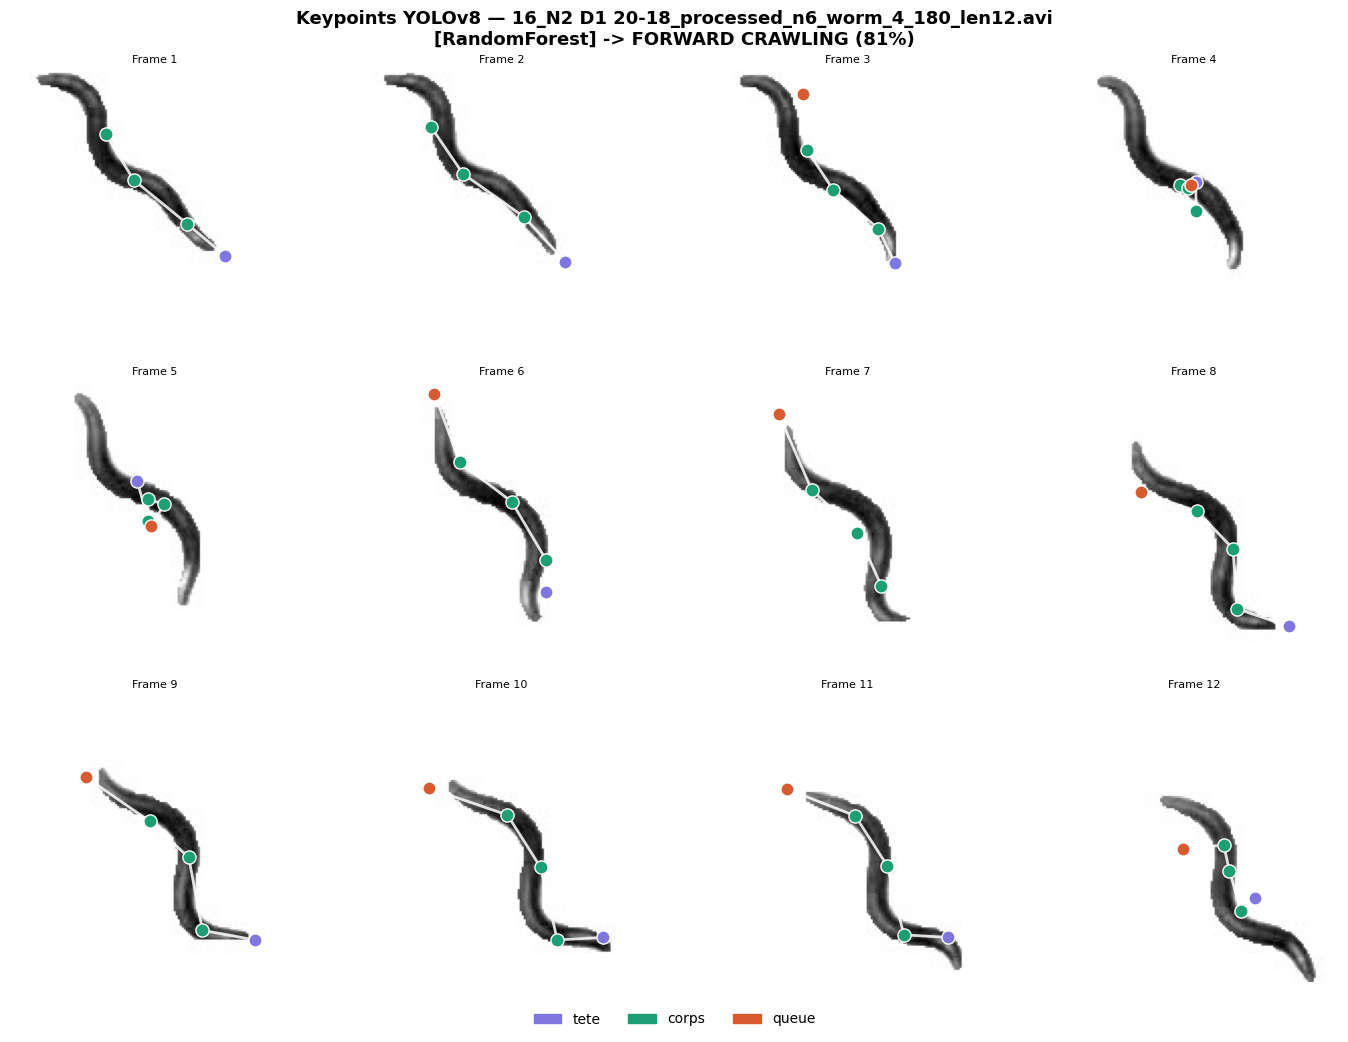

12 frames | -> /kaggle/working/pipeline_outputs/keypoints_grid.png


In [20]:
detected = [(fd['frame'], fd['kpts'])
             for fd in frame_data if fd['detected'] and fd['kpts'] is not None]

n_show = min(len(detected), 12)
ncols  = 4
nrows  = (n_show + ncols - 1) // ncols
KPT_COLORS = ['#7F77DD'] + ['#1D9E75'] * 3 + ['#D85A30']

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.5))
axes = np.array(axes).reshape(-1)

for idx in range(n_show):
    frame_rgb, kpts = detected[idx]
    ax = axes[idx]
    ax.imshow(frame_rgb)
    vis = kpts[kpts[:, 2] > VIS_THRESH]
    for i in range(len(vis) - 1):
        ax.plot([vis[i,0], vis[i+1,0]], [vis[i,1], vis[i+1,1]],
                '-', color='white', lw=2, alpha=0.85)
    for i, kp in enumerate(kpts):
        if kp[2] > VIS_THRESH:
            ax.scatter(kp[0], kp[1], c=KPT_COLORS[min(i, len(KPT_COLORS)-1)],
                       s=90, zorder=5, edgecolors='white', linewidths=1)
    ax.set_title(f'Frame {idx+1}', fontsize=8)
    ax.axis('off')

for idx in range(n_show, len(axes)): axes[idx].axis('off')

fig.legend(handles=[
    mpatches.Patch(color='#7F77DD', label='tete'),
    mpatches.Patch(color='#1D9E75', label='corps'),
    mpatches.Patch(color='#D85A30', label='queue'),
], loc='lower center', ncol=3, fontsize=10, frameon=False, bbox_to_anchor=(0.5, 0))
fig.suptitle(
    f'Keypoints YOLOv8 — {os.path.basename(VIDEO_PATH)}\n'
    f'[RandomForest] -> {label_rf.upper()} ({conf_rf*100:.0f}%)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(f'{OUTPUT_DIR}/keypoints_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'{n_show} frames | -> {OUTPUT_DIR}/keypoints_grid.png')


## 6. Résumé : probabilités + trajectoire

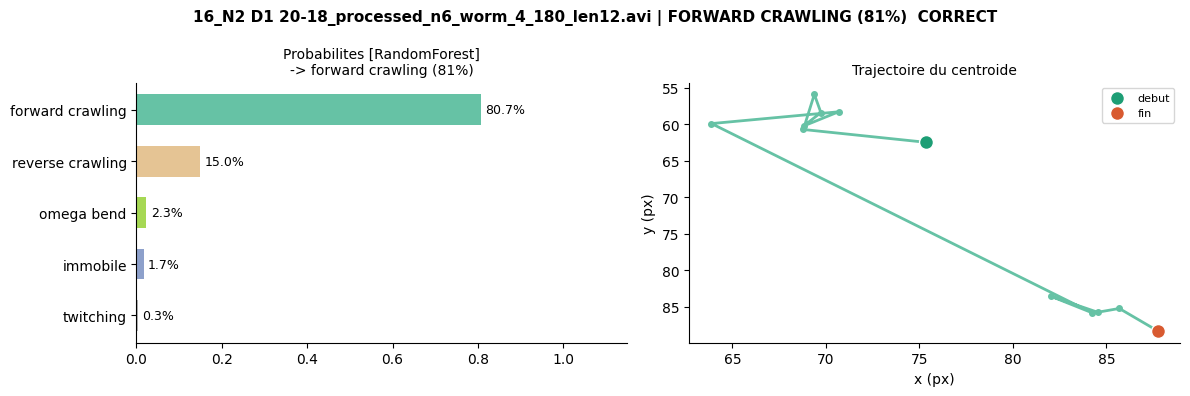

-> /kaggle/working/pipeline_outputs/resume.png


In [21]:
COLORS     = plt.cm.Set2(np.linspace(0, 1, len(le.classes_)))
cls_colors = {c: COLORS[i] for i, c in enumerate(le.classes_)}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sorted_pairs = sorted(zip(le.classes_, proba_rf), key=lambda x: x[1])
cls_names = [p[0] for p in sorted_pairs]
cls_probs = [p[1] for p in sorted_pairs]
bars = ax1.barh(cls_names, cls_probs,
                color=[cls_colors[c] for c in cls_names], edgecolor='none', height=0.6)
for bar, prob in zip(bars, cls_probs):
    ax1.text(prob + 0.01, bar.get_y() + bar.get_height()/2,
             f'{prob*100:.1f}%', va='center', fontsize=9)
ax1.set_xlim(0, 1.15)
ax1.set_title(f'Probabilites [RandomForest]\n-> {label_rf} ({conf_rf*100:.0f}%)', fontsize=10)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

cx_list = [fd['cx'] for fd in frame_data if fd['detected']]
cy_list = [fd['cy'] for fd in frame_data if fd['detected']]
if len(cx_list) >= 2:
    ax2.plot(cx_list, cy_list, '-o', color=cls_colors.get(label_rf, 'gray'), lw=2, ms=4)
    ax2.scatter(cx_list[0],  cy_list[0],  s=100, color='#1D9E75', zorder=5,
                label='debut', edgecolors='white', lw=1)
    ax2.scatter(cx_list[-1], cy_list[-1], s=100, color='#D85A30', zorder=5,
                label='fin',   edgecolors='white', lw=1)
    ax2.invert_yaxis(); ax2.legend(fontsize=8)
ax2.set_xlabel('x (px)'); ax2.set_ylabel('y (px)')
ax2.set_title('Trajectoire du centroide', fontsize=10)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

verdict_str = 'CORRECT' if label_rf == true_label else f'INCORRECT (vrai : {true_label})'
fig.suptitle(
    f'{os.path.basename(VIDEO_PATH)} | {label_rf.upper()} ({conf_rf*100:.0f}%)  {verdict_str}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/resume.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'-> {OUTPUT_DIR}/resume.png')
